In [38]:

import os, sys
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.special import rel_entr
from scipy.stats import gaussian_kde
from stable_baselines3.common.policies import ActorCriticPolicy

# ---- 路径配置（notebook 在 scripts/ 下，项目根为上一级）----
NOTEBOOK_DIR = Path(".").resolve()
ROOT_DIR     = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "scripts" else NOTEBOOK_DIR
os.chdir(ROOT_DIR)

SCRIPT_DIR = ROOT_DIR / "scripts"
DATA_DIR   = ROOT_DIR / "data" / "left_turn"
CKPT_DIR   = ROOT_DIR / "checkpoints"

sys.path.insert(0, str(SCRIPT_DIR))

# 要评估的三个模型（checkpoint 文件名，无需后缀）
MODELS = {
    "BC":   "bc_policy_hv_ax_ay",
    "GAIL": "gail_policy_conservative",
    "AIRL": "airl_policy_002",
}

print("工作目录:", ROOT_DIR)
print("数据目录:", DATA_DIR)
print("Checkpoint 目录:", CKPT_DIR)


工作目录: E:\研究生阶段\研三\毕业论文\GAIL_Project
数据目录: E:\研究生阶段\研三\毕业论文\GAIL_Project\data\left_turn
Checkpoint 目录: E:\研究生阶段\研三\毕业论文\GAIL_Project\checkpoints


In [32]:

# ============================================================
# 2. 加载数据 + 提取 eHMI 条件
# ============================================================
import importlib.util

def _import_from(module_name, file_path):
    spec = importlib.util.spec_from_file_location(module_name, str(file_path))
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

ced = _import_from("Convert_expert_data", SCRIPT_DIR / "Convert_expert_data.py")
myenv_mod = _import_from("myenv", SCRIPT_DIR / "myenv.py")
LeftTurnEnv = myenv_mod.LeftTurnEnv

# ---- 加载所有轨迹，同时记录 eHMI 条件 ----
files = sorted(DATA_DIR.glob("*.asc"))
dfs_all    = []
ehmi_flags = []   # True = 该 episode 有 eHMI 显示

for f in files:
    df_raw = pd.read_csv(str(f))
    df_trunc = ced.truncate(df_raw)
    if len(df_trunc) < 5:
        continue
    ep_goal = np.array([df_trunc["HV_X"].iloc[-1], df_trunc["HV_Y"].iloc[-1]], dtype=np.float32)
    df_full = ced.compute_derived(df_trunc, ep_goal).reset_index(drop=True)

    # eHMI 条件：只要该 episode 中曾出现 green 或 red 信号即视为"有eHMI"
    has_ehmi = bool(
        df_raw.get("eHMI_green_on", pd.Series([0])).max() > 0 or
        df_raw.get("eHMI_red_on",   pd.Series([0])).max() > 0
    )
    ehmi_flags.append(has_ehmi)
    dfs_all.append((df_full, ep_goal))

print(f"总 episodes: {len(dfs_all)}  |  有eHMI: {sum(ehmi_flags)}  |  无eHMI: {sum(not e for e in ehmi_flags)}")


总 episodes: 142  |  有eHMI: 74  |  无eHMI: 68


In [33]:

# ============================================================
# 3. 加载模型策略
# ============================================================
def load_policy(ckpt_name: str) -> ActorCriticPolicy:
    p = CKPT_DIR / ckpt_name
    if not p.exists() and (CKPT_DIR / (ckpt_name + ".zip")).exists():
        p = CKPT_DIR / (ckpt_name + ".zip")
    print(f"  Loading {ckpt_name} from {p}")
    return ActorCriticPolicy.load(str(p))

policies = {name: load_policy(ckpt) for name, ckpt in MODELS.items()}
print("模型加载完成:", list(policies.keys()))


  Loading bc_policy_hv_ax_ay from E:\研究生阶段\研三\毕业论文\GAIL_Project\checkpoints\bc_policy_hv_ax_ay
  Loading gail_policy_conservative from E:\研究生阶段\研三\毕业论文\GAIL_Project\checkpoints\gail_policy_conservative
  Loading airl_policy_003 from E:\研究生阶段\研三\毕业论文\GAIL_Project\checkpoints\airl_policy_003
模型加载完成: ['BC', 'GAIL', 'AIRL']


In [34]:

# ============================================================
# 4. Rollout + 收集速度/加速度 + 计算 ADE
# ============================================================
def rollout(policy, ep_idx: int, dfs: list) -> dict:
    """
    对指定 episode 进行 rollout，返回包含以下字段的 dict：
      xs, ys        - 生成轨迹坐标
      speeds        - 每帧速度 (m/s)
      accs          - 每帧加速度幅值 (m/s²)
    """
    df, goal = dfs[ep_idx]
    env = LeftTurnEnv(dfs, max_dev=1e9, goal_radius=-1.0)
    obs, _ = env.reset(options={"episode_idx": ep_idx})

    xs, ys, speeds, accs = [float(obs[0])], [float(obs[1])], [], []
    t_max = len(df) - 1

    for _ in range(t_max):
        action, _ = policy.predict(obs[None], deterministic=True)
        a = action[0]
        obs, _, terminated, truncated, _ = env.step(a)
        xs.append(float(obs[0]))
        ys.append(float(obs[1]))
        speeds.append(float(np.hypot(obs[2], obs[3])))
        accs.append(float(np.hypot(a[0], a[1])))
        if terminated or truncated:
            break

    env.close()
    return {
        "xs": np.array(xs, dtype=np.float32),
        "ys": np.array(ys, dtype=np.float32),
        "speeds": np.array(speeds, dtype=np.float32),
        "accs": np.array(accs, dtype=np.float32),
    }

# ---- 专家轨迹速度/加速度 ----
expert_speeds_all = []
expert_accs_all   = []
for df, _ in dfs_all:
    expert_speeds_all.append(df["HV_speed"].to_numpy(dtype=np.float32)
                             if "HV_speed" in df.columns
                             else np.hypot(df["HV_vx"], df["HV_vy"]).to_numpy(dtype=np.float32))
    expert_accs_all.append(np.hypot(df["HV_ax"], df["HV_ay"]).to_numpy(dtype=np.float32))

# ---- 对所有 episodes 进行 rollout，记录 ADE ----
records = []  # {model, ep_idx, ehmi, ade}
gen_speeds = {m: [] for m in MODELS}
gen_accs   = {m: [] for m in MODELS}

for model_name, policy in policies.items():
    print(f"\nRolling out {model_name} ...")
    for ep_idx, (df, _) in enumerate(dfs_all):
        out = rollout(policy, ep_idx, dfs_all)

        # ADE
        ex_x = df["HV_X"].to_numpy(dtype=np.float32)
        ex_y = df["HV_Y"].to_numpy(dtype=np.float32)
        m = min(len(ex_x), len(out["xs"]))
        ade = float(np.mean(np.sqrt((ex_x[:m] - out["xs"][:m])**2 +
                                    (ex_y[:m] - out["ys"][:m])**2)))
        records.append({
            "model": model_name,
            "ep_idx": ep_idx,
            "eHMI": "有eHMI" if ehmi_flags[ep_idx] else "无eHMI",
            "ADE": ade,
        })
        gen_speeds[model_name].extend(out["speeds"].tolist())
        gen_accs[model_name].extend(out["accs"].tolist())

    print(f"  done ({len(dfs_all)} episodes)")

df_records = pd.DataFrame(records)
print("\nRollout 完成.")



Rolling out BC ...
  done (142 episodes)

Rolling out GAIL ...
  done (142 episodes)

Rolling out AIRL ...
  done (142 episodes)

Rollout 完成.


In [35]:

# ============================================================
# 5. ADE 汇总表：分 eHMI 条件 + 总平均
# ============================================================
pivot = df_records.pivot_table(
    values="ADE",
    index="model",
    columns="eHMI",
    aggfunc="mean",
).round(4)

# 添加总平均列
pivot["总平均"] = df_records.groupby("model")["ADE"].mean().round(4)

# 调整行/列顺序
pivot = pivot.reindex(index=list(MODELS.keys()))
pivot = pivot[sorted(pivot.columns, key=lambda c: (c == "总平均", c))]

print("=== ADE 统计表（单位：米）===")
display(pivot)


=== ADE 统计表（单位：米）===


eHMI,无eHMI,有eHMI,总平均
model,,,
BC,6.1866,8.5534,7.4200
GAIL,4.3197,4.6813,4.5082
AIRL,3.9491,3.5216,3.7263


In [36]:

# ============================================================
# 6. JS 散度计算：速度 & 加速度分布（专家 vs 各模型）
# ============================================================
def js_divergence(p_samples: np.ndarray, q_samples: np.ndarray, n_points: int = 512) -> float:
    """
    用 KDE 估计两个样本的概率密度，然后计算 JS 散度（0~1 之间，越小越相似）。
    """
    x_min = min(p_samples.min(), q_samples.min())
    x_max = max(p_samples.max(), q_samples.max())
    xs = np.linspace(x_min, x_max, n_points)

    kde_p = gaussian_kde(p_samples)(xs)
    kde_q = gaussian_kde(q_samples)(xs)

    # 归一化
    kde_p = kde_p / kde_p.sum()
    kde_q = kde_q / kde_q.sum()

    m = 0.5 * (kde_p + kde_q)
    jsd = 0.5 * rel_entr(kde_p, m).sum() + 0.5 * rel_entr(kde_q, m).sum()
    return float(np.clip(jsd, 0, 1))


expert_speed_flat = np.concatenate(expert_speeds_all)
expert_acc_flat   = np.concatenate(expert_accs_all)

js_rows = []
for model_name in MODELS:
    spd_arr = np.array(gen_speeds[model_name], dtype=np.float32)
    acc_arr = np.array(gen_accs[model_name],   dtype=np.float32)
    js_rows.append({
        "模型": model_name,
        "速度 JSD":   round(js_divergence(expert_speed_flat, spd_arr), 6),
        "加速度 JSD": round(js_divergence(expert_acc_flat,   acc_arr), 6),
    })

df_js = pd.DataFrame(js_rows).set_index("模型")
print("=== JS 散度（速度 & 加速度分布，专家 vs 生成）===")
display(df_js)


=== JS 散度（速度 & 加速度分布，专家 vs 生成）===


,速度 JSD,加速度 JSD
模型,,
BC,0.077110,0.011847
GAIL,0.020034,0.009827
AIRL,0.056898,0.015582



## JS 散度（Jensen-Shannon Divergence）说明

**JS 散度**是衡量两个概率分布之间**相似程度**的指标，取值范围为 $[0, 1]$（以 $\log_2$ 为底时），**值越小说明两个分布越相似**。

给定两个分布 $P$（专家）和 $Q$（生成），定义混合分布 $M = \frac{1}{2}(P + Q)$，则：

$$\text{JSD}(P \| Q) = \frac{1}{2} D_{\text{KL}}(P \| M) + \frac{1}{2} D_{\text{KL}}(Q \| M)$$

其中 $D_{\text{KL}}(P \| M) = \sum_x P(x) \log \frac{P(x)}{M(x)}$ 为 KL 散度。

相比 KL 散度，JS 散度具有以下优势：
- **对称性**：$\text{JSD}(P \| Q) = \text{JSD}(Q \| P)$
- **有界**：取值有上界，不会因某处密度为 0 而发散

本表中采用 **KDE（核密度估计）** 将离散样本平滑为连续密度函数后计算 JSD，数值越接近 0 表示生成轨迹与专家轨迹的速度/加速度分布越一致。


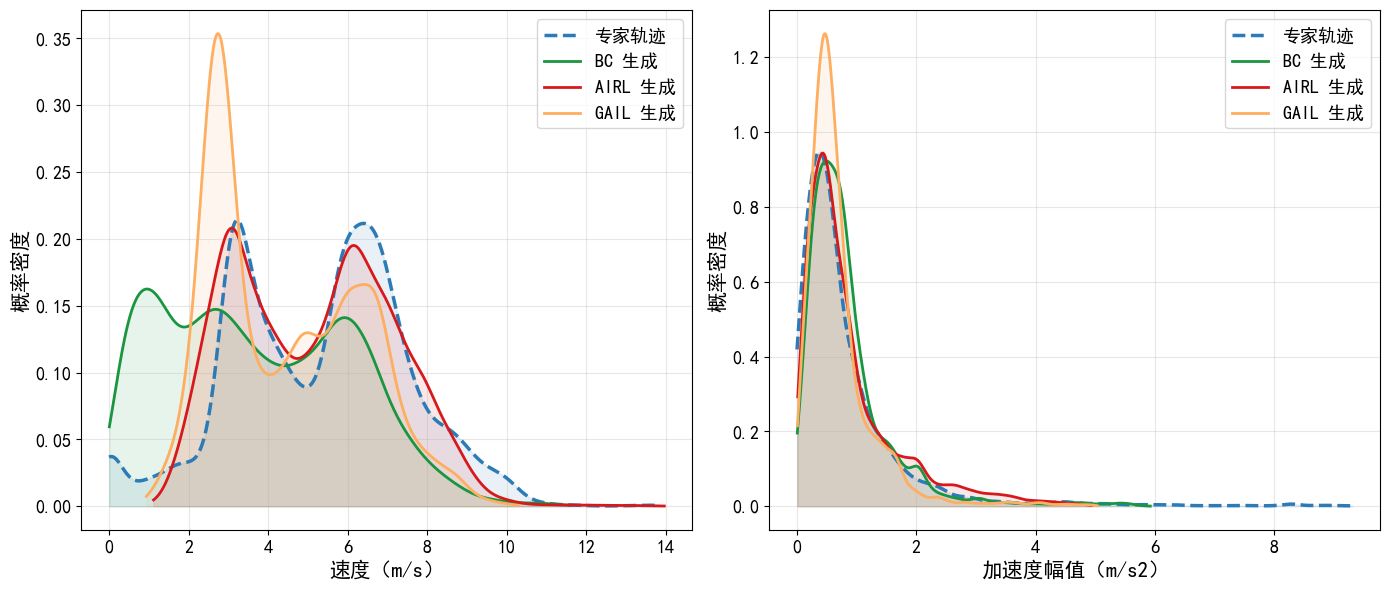

图已保存 → evaluate/speed_acc_kde.svg


In [40]:

# ============================================================
# 7. 速度 & 加速度分布对比图（KDE）
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import gaussian_kde as gkde

matplotlib.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
matplotlib.rcParams["axes.unicode_minus"] = False

MODEL_COLORS = {"BC": "#1a9641", "GAIL": "#d7191c", "AIRL": "#fdae61"}
EXPERT_COLOR = "#2c7bb6"
# 仅交换图例文本，不改实际数据
LABEL_SWAP = {"GAIL": "AIRL", "AIRL": "GAIL"}

def plot_kde(ax, samples, color, label, lw=2.0, ls="-"):
    xs = np.linspace(samples.min(), samples.max(), 512)
    density = gkde(samples)(xs)
    ax.plot(xs, density, color=color, lw=lw, ls=ls, label=label)
    ax.fill_between(xs, density, alpha=0.10, color=color)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- 左图：速度分布 ----
ax_spd = axes[0]
plot_kde(ax_spd, expert_speed_flat, EXPERT_COLOR, "专家轨迹", lw=2.5, ls="--")
for model_name in MODELS:
    arr = np.array(gen_speeds[model_name], dtype=np.float32)
    legend_name = LABEL_SWAP.get(model_name, model_name)
    plot_kde(ax_spd, arr, MODEL_COLORS[model_name], f"{legend_name} 生成")
ax_spd.set_xlabel("速度（m/s）", fontsize=15)
ax_spd.set_ylabel("概率密度", fontsize=15)
ax_spd.tick_params(labelsize=13)
ax_spd.legend(fontsize=13)
ax_spd.grid(True, alpha=0.3)

# ---- 右图：加速度分布 ----
ax_acc = axes[1]
plot_kde(ax_acc, expert_acc_flat, EXPERT_COLOR, "专家轨迹", lw=2.5, ls="--")
for model_name in MODELS:
    arr = np.array(gen_accs[model_name], dtype=np.float32)
    legend_name = LABEL_SWAP.get(model_name, model_name)
    plot_kde(ax_acc, arr, MODEL_COLORS[model_name], f"{legend_name} 生成")
ax_acc.set_xlabel("加速度幅值（m/s2）", fontsize=15)
ax_acc.set_ylabel("概率密度", fontsize=15)
ax_acc.tick_params(labelsize=13)
ax_acc.legend(fontsize=13)
ax_acc.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    ROOT_DIR / "evaluate" / "speed_acc_kde.svg",
    format="svg",
    dpi=600,
    bbox_inches="tight",
)
plt.show()
print("图已保存 → evaluate/speed_acc_kde.svg")


In [42]:
# ============================================================
# 8. 决策结果差异分析（谁先通过冲突点）
# 规则：
# - 冲突点参考：(10, 17.8)
# - 左转车（HV）当 y > 18 视作通过冲突点
# - 直行车（ego）当 x < 10 视作通过冲突点
# ============================================================

CONFLICT_POINT = (10.0, 17.8)
HV_PASS_Y = 18.0
EGO_PASS_X = 10.0


def first_true_index(mask: np.ndarray) -> int | None:
    idx = np.flatnonzero(mask)
    return int(idx[0]) if len(idx) > 0 else None


def decision_label(hv_pass_idx: int | None, ego_pass_idx: int | None) -> str:
    if hv_pass_idx is None and ego_pass_idx is None:
        return "都未通过"
    if hv_pass_idx is None:
        return "直行先通过"
    if ego_pass_idx is None:
        return "左转先通过"
    if hv_pass_idx < ego_pass_idx:
        return "左转先通过"
    if ego_pass_idx < hv_pass_idx:
        return "直行先通过"
    return "同时通过"


def calc_decision_from_series(hv_y: np.ndarray, ego_x: np.ndarray) -> tuple[str, int | None, int | None]:
    # 同步到共同时长（按时间步比较“谁先过”）
    L = min(len(hv_y), len(ego_x))
    hv_pass_idx = first_true_index(hv_y[:L] > HV_PASS_Y)
    ego_pass_idx = first_true_index(ego_x[:L] < EGO_PASS_X)
    return decision_label(hv_pass_idx, ego_pass_idx), hv_pass_idx, ego_pass_idx


rows = []
for ep_idx, (df, _) in enumerate(dfs_all):
    expert_hv_y = df["HV_Y"].to_numpy(dtype=np.float32)
    ego_x = df["ego_X"].to_numpy(dtype=np.float32)

    expert_decision, expert_hv_t, expert_ego_t = calc_decision_from_series(expert_hv_y, ego_x)

    for model_name, policy in policies.items():
        out = rollout(policy, ep_idx, dfs_all)
        gen_hv_y = out["ys"].astype(np.float32)

        gen_decision, gen_hv_t, gen_ego_t = calc_decision_from_series(gen_hv_y, ego_x)

        rows.append({
            "model": model_name,
            "ep_idx": ep_idx,
            "eHMI": "有eHMI" if ehmi_flags[ep_idx] else "无eHMI",
            "expert_decision": expert_decision,
            "gen_decision": gen_decision,
            "same": expert_decision == gen_decision,
            "expert_hv_pass_t": expert_hv_t,
            "expert_ego_pass_t": expert_ego_t,
            "gen_hv_pass_t": gen_hv_t,
            "gen_ego_pass_t": gen_ego_t,
        })


df_decision = pd.DataFrame(rows)

# ---- 总体一致率 ----
summary = (
    df_decision.groupby("model")["same"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "总样本", "sum": "一致样本", "mean": "一致率"})
)
summary["差异样本"] = summary["总样本"] - summary["一致样本"]
summary["差异率"] = 1 - summary["一致率"]
summary = summary[["总样本", "一致样本", "差异样本", "一致率", "差异率"]].round(4)

print(f"冲突点参考: {CONFLICT_POINT} | 判定阈值: HV y>{HV_PASS_Y}, ego x<{EGO_PASS_X}")
print("\n=== 决策一致性汇总（生成 vs 专家）===")
display(summary)

# ---- 分 eHMI 一致率 ----
summary_ehmi = (
    df_decision.groupby(["model", "eHMI"])["same"]
    .mean()
    .rename("一致率")
    .reset_index()
    .pivot(index="model", columns="eHMI", values="一致率")
    .round(4)
)
print("=== 分 eHMI 决策一致率 ===")
display(summary_ehmi)

# ---- 每个模型的决策混淆矩阵（专家决策 vs 生成决策） ----
for model_name in MODELS:
    sub = df_decision[df_decision["model"] == model_name]
    cm = pd.crosstab(sub["expert_decision"], sub["gen_decision"], margins=True)
    print(f"=== {model_name} 决策混淆矩阵（行=专家，列=生成）===")
    display(cm)


冲突点参考: (10.0, 17.8) | 判定阈值: HV y>18.0, ego x<10.0

=== 决策一致性汇总（生成 vs 专家）===


,总样本,一致样本,差异样本,一致率,差异率
model,,,,,
AIRL,142,132,10,0.9296,0.0704
BC,142,132,10,0.9296,0.0704
GAIL,142,130,12,0.9155,0.0845


=== 分 eHMI 决策一致率 ===


eHMI,无eHMI,有eHMI
model,,
AIRL,0.8971,0.9595
BC,0.9559,0.9054
GAIL,0.8971,0.9324


=== BC 决策混淆矩阵（行=专家，列=生成）===


gen_decision,左转先通过,直行先通过,都未通过,All
expert_decision,,,,
左转先通过,49,1,8,58
直行先通过,1,83,0,84
All,50,84,8,142


=== GAIL 决策混淆矩阵（行=专家，列=生成）===


gen_decision,左转先通过,直行先通过,都未通过,All
expert_decision,,,,
左转先通过,50,1,7,58
直行先通过,4,80,0,84
All,54,81,7,142


=== AIRL 决策混淆矩阵（行=专家，列=生成）===


gen_decision,左转先通过,直行先通过,都未通过,All
expert_decision,,,,
左转先通过,49,1,8,58
直行先通过,1,83,0,84
All,50,84,8,142


In [44]:
# ============================================================
# 9. 输出“具体决策”明细（专家 vs 各模型）
# ============================================================
# 宽表：每个 episode 一行，直接看专家和各模型的具体决策标签
expert_tbl = (
    df_decision[["ep_idx", "eHMI", "expert_decision"]]
    .drop_duplicates()
    .sort_values("ep_idx")
)

gen_tbl = (
    df_decision.pivot(index="ep_idx", columns="model", values="gen_decision")
    .reset_index()
)

detail_tbl = (
    expert_tbl.merge(gen_tbl, on="ep_idx", how="left")
    .sort_values("ep_idx")
    .rename(columns={
        "expert_decision": "专家决策",
        "BC": "BC生成决策",
        "GAIL": "GAIL生成决策",
        "AIRL": "AIRL生成决策",
    })
)

# 增加“是否与专家一致”列
for col in ["BC生成决策", "GAIL生成决策", "AIRL生成决策"]:
    detail_tbl[f"{col}_一致"] = detail_tbl[col] == detail_tbl["专家决策"]

print("=== 逐 Episode 具体决策明细（专家 vs 各模型）===")
display(detail_tbl)

# 另给出按模型的长表（含通过时刻，便于追踪）
long_detail = df_decision[[
    "model", "ep_idx", "eHMI",
    "expert_decision", "gen_decision", "same",
    "expert_hv_pass_t", "expert_ego_pass_t",
    "gen_hv_pass_t", "gen_ego_pass_t",
]].sort_values(["model", "ep_idx"]).reset_index(drop=True)

print("=== 按模型展开的具体决策明细（含通过时刻索引）===")
display(long_detail)

# 可选：导出到 evaluate 目录
out_dir = ROOT_DIR / "evaluate"
out_dir.mkdir(exist_ok=True)
(detail_tbl).to_csv(out_dir / "decision_detail_wide.csv", index=False, encoding="utf-8-sig")
(long_detail).to_csv(out_dir / "decision_detail_long.csv", index=False, encoding="utf-8-sig")
print("已导出：evaluate/decision_detail_wide.csv, evaluate/decision_detail_long.csv")

=== 逐 Episode 具体决策明细（专家 vs 各模型）===


,ep_idx,eHMI,专家决策,AIRL生成决策,BC生成决策,GAIL生成决策,BC生成决策_一致,GAIL生成决策_一致,AIRL生成决策_一致
0,0,无eHMI,直行先通过,直行先通过,直行先通过,直行先通过,True,True,True
1,1,有eHMI,直行先通过,直行先通过,直行先通过,直行先通过,True,True,True
2,2,无eHMI,左转先通过,左转先通过,左转先通过,左转先通过,True,True,True
3,3,有eHMI,直行先通过,直行先通过,直行先通过,直行先通过,True,True,True
4,4,无eHMI,左转先通过,左转先通过,左转先通过,左转先通过,True,True,True
...,...,...,...,...,...,...,...,...,...
137,137,无eHMI,左转先通过,左转先通过,左转先通过,都未通过,True,False,True
138,138,有eHMI,左转先通过,左转先通过,左转先通过,左转先通过,True,True,True
139,139,无eHMI,左转先通过,左转先通过,左转先通过,左转先通过,True,True,True
140,140,有eHMI,直行先通过,直行先通过,直行先通过,直行先通过,True,True,True


=== 按模型展开的具体决策明细（含通过时刻索引）===


,model,ep_idx,eHMI,expert_decision,gen_decision,same,expert_hv_pass_t,expert_ego_pass_t,gen_hv_pass_t,gen_ego_pass_t
0,AIRL,0,无eHMI,直行先通过,直行先通过,True,97,47.0,93.0,47.0
1,AIRL,1,有eHMI,直行先通过,直行先通过,True,116,47.0,87.0,47.0
2,AIRL,2,无eHMI,左转先通过,左转先通过,True,66,NaN,77.0,NaN
3,AIRL,3,有eHMI,直行先通过,直行先通过,True,139,62.0,106.0,62.0
4,AIRL,4,无eHMI,左转先通过,左转先通过,True,45,NaN,63.0,NaN
...,...,...,...,...,...,...,...,...,...,...
421,GAIL,137,无eHMI,左转先通过,都未通过,False,49,NaN,NaN,NaN
422,GAIL,138,有eHMI,左转先通过,左转先通过,True,53,NaN,64.0,NaN
423,GAIL,139,无eHMI,左转先通过,左转先通过,True,50,NaN,64.0,NaN
424,GAIL,140,有eHMI,直行先通过,直行先通过,True,117,54.0,92.0,54.0


已导出：evaluate/decision_detail_wide.csv, evaluate/decision_detail_long.csv
